In [29]:
# ── Load your data from the feature store ────────────────────────
import pandas as pd
from pathlib import Path

STORE = Path('/kaggle/input/notebooks/waithakafrancis/data-pipeline/feature_store')

# For R-GAN (Pipeline A)
a_train = pd.read_parquet(STORE / 'pipeline_a_train.parquet')

# For f-AnoGAN (Pipeline B)
b_train = pd.read_parquet(STORE / 'pipeline_b_train.parquet')

# Holdout — used to evaluate BOTH models
holdout = pd.read_parquet(STORE / 'fraud_holdout.parquet')

print('R-GAN training shape    :', a_train.shape)
print('f-AnoGAN training       :', b_train.shape)
print('Fraud holdout           :', holdout.shape)


R-GAN training shape    : (250170, 51)
f-AnoGAN training       : (284315, 51)
Fraud holdout           : (492, 51)


In [30]:
# ── Verify your data loaded correctly ────────────────────────────
# R-GAN: should see ~9% fraud rate (post-SMOTE)
fraud_rate_a = a_train['Class'].mean()
print(f'Pipeline A fraud rate: {fraud_rate_a:.2%}')   # expect ~9%

# f-AnoGAN: must have 0% fraud
fraud_rate_b = b_train['Class'].mean()
print(f'Pipeline B fraud rate: {fraud_rate_b:.2%}')   # expect 0.00%

# Feature count: should be 51
print(f'Features: {a_train.shape[1]}')               # expect 51

# Separate features and labels for R-GAN
X_rgan = a_train.drop(columns=['Class'])
y_rgan = a_train['Class']
print(f'X shape: {X_rgan.shape}, fraud samples: {y_rgan.sum():,}')


Pipeline A fraud rate: 9.09%
Pipeline B fraud rate: 0.00%
Features: 51
X shape: (250170, 50), fraud samples: 22,742


In [31]:
import time
import json
import warnings
import numpy as np
import pandas as pd
from pathlib import Path
from dataclasses import dataclass, asdict
from copy import deepcopy

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import wandb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    f1_score, precision_score, recall_score,
    roc_auc_score, classification_report
)

import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')

DEVICE      = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
GLOBAL_SEED = 42

def set_seed(seed):
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False

set_seed(GLOBAL_SEED)
print(f'Device: {DEVICE}')
print('Deterministic mode enabled.')

Device: cuda
Deterministic mode enabled.


In [32]:
a_val   = pd.read_parquet(STORE / 'pipeline_a_val.parquet')

# ── Schema validation  ───────────────────────────────────────
EXPECTED_COLS   = 51
EXPECTED_TARGET = 'Class'

def validate_schema(df, name, expected_fraud_rate=None):
    """Validates shape, columns, types, nulls, and fraud rate."""
    errors = []

    # Column count
    if df.shape[1] != EXPECTED_COLS:
        errors.append(
            f'{name}: expected {EXPECTED_COLS} cols, got {df.shape[1]}'
        )

    # Target column present
    if EXPECTED_TARGET not in df.columns:
        errors.append(f'{name}: missing target column "{EXPECTED_TARGET}"')

    # No nulls
    null_count = df.isnull().sum().sum()
    if null_count > 0:
        errors.append(f'{name}: contains {null_count} null values')

    # No duplicate rows
    dup_count = df.duplicated().sum()
    if dup_count > 0:
        print(f'  WARNING: {name} contains {dup_count} duplicate rows')

    # Fraud rate check
    if expected_fraud_rate is not None:
        actual = df[EXPECTED_TARGET].mean()
        if abs(actual - expected_fraud_rate) > 0.05:
            errors.append(
                f'{name}: fraud rate {actual:.2%} '
                f'deviates from expected {expected_fraud_rate:.2%}'
            )

    # Class values must be binary
    unique_classes = set(df[EXPECTED_TARGET].unique())
    if not unique_classes.issubset({0, 1}):
        errors.append(f'{name}: Class contains non-binary values: {unique_classes}')

    if errors:
        for e in errors:
            print(f'  SCHEMA ERROR — {e}')
        raise ValueError(f'Schema validation failed for {name}.')
    else:
        print(f'  {name}: OK — shape={df.shape}, '
              f'fraud_rate={df[EXPECTED_TARGET].mean():.2%}, '
              f'nulls=0')

print('Running schema validation...')
validate_schema(b_train, 'b_train',  expected_fraud_rate=0.00)
validate_schema(a_val,   'a_val',    expected_fraud_rate=None)
validate_schema(holdout, 'holdout',  expected_fraud_rate=1.00)

# Hard assertion — Pipeline B must never contain fraud
assert b_train['Class'].sum() == 0, 'STOP: Pipeline B contaminated!'
# Holdout must be all fraud
assert holdout['Class'].sum() == len(holdout), 'STOP: Holdout missing fraud!'

print('All schema checks passed.')

Running schema validation...
  b_train: OK — shape=(284315, 51), fraud_rate=0.00%, nulls=0
  a_val: OK — shape=(56962, 51), fraud_rate=0.13%, nulls=0
  holdout: OK — shape=(492, 51), fraud_rate=100.00%, nulls=0
All schema checks passed.


In [33]:
@dataclass
class FAnoGANConfig:
    # ── Data ──────────────────────────────────────────────────────────────
    target_col: str   = 'Class'
    n_features: int   = 50
    val_size:   float = 0.2

    # ── Architecture ──────────────────────────────────────────────────────
    # Optional improvement: smaller latent dim (32-64) often works better
    # for tabular data — less risk of the encoder underfitting
    latent_dim:  int = 64        # reduced from 128
    gen_dim_1:   int = 256
    gen_dim_2:   int = 512
    disc_dim_1:  int = 512
    disc_dim_2:  int = 256
    enc_dim_1:   int = 256
    enc_dim_2:   int = 512

    # ── Phase 1: WGAN-GP ──────────────────────────────────────────────────
    wgan_epochs:     int   = 100
    wgan_batch:      int   = 256
    wgan_lr_g:       float = 1e-4
    wgan_lr_d:       float = 1e-4
    wgan_n_critic:   int   = 5
    wgan_gp_lambda:  float = 10.0
    adam_beta1:      float = 0.5
    adam_beta2:      float = 0.9

    # ── Early stopping ────────────────────────────────────────────────────
    wgan_patience:   int   = 15   # stop if W-dist doesn't improve
    enc_patience:    int   = 10   # stop if enc_loss doesn't improve

    # ── Phase 2: Encoder ──────────────────────────────────────────────────
    enc_epochs:  int   = 50
    enc_batch:   int   = 256
    enc_lr:      float = 1e-4
    kappa:       float = 1.0


cfg            = FAnoGANConfig()
cfg.n_features = b_train.shape[1] - 1

print(
    f'Config: n_features={cfg.n_features}, latent_dim={cfg.latent_dim}, '
    f'wgan_epochs={cfg.wgan_epochs}, enc_epochs={cfg.enc_epochs}'
)

Config: n_features=50, latent_dim=64, wgan_epochs=100, enc_epochs=50


In [34]:
run = wandb.init(
    project = 'PRINCIPLES AND ENGINEERING APPLICATIONS OF AI',
    name    = 'fanogan-pipeline-b-run-1',
    tags    = ['f-AnoGAN', 'Pipeline-B', 'anomaly-detection', 'WGAN-GP'],
    config  = asdict(cfg),
)

# Sync config back for sweep compatibility
wcfg             = wandb.config
cfg.n_features   = wcfg.n_features
cfg.latent_dim   = wcfg.latent_dim
cfg.wgan_epochs  = wcfg.wgan_epochs
cfg.wgan_batch   = wcfg.wgan_batch
cfg.wgan_lr_g    = wcfg.wgan_lr_g
cfg.wgan_lr_d    = wcfg.wgan_lr_d
cfg.wgan_n_critic= wcfg.wgan_n_critic
cfg.wgan_gp_lambda = wcfg.wgan_gp_lambda
cfg.enc_epochs   = wcfg.enc_epochs
cfg.enc_lr       = wcfg.enc_lr
cfg.kappa        = wcfg.kappa

print('W&B run initialised:', run.name)
print('W&B project URL    :', run.url)

W&B run initialised: fanogan-pipeline-b-run-1
W&B project URL    : https://wandb.ai/kkipngenokoech-carnegie-mellon-university/PRINCIPLES%20AND%20ENGINEERING%20APPLICATIONS%20OF%20AI/runs/5riwdg95


In [36]:
FEATURE_COLS = [c for c in b_train.columns if c != cfg.target_col]

# ── 80/20 split — both halves are normal only ─────────────────────────────
X_all = b_train[FEATURE_COLS].values.astype(np.float32)

X_train_raw, X_val_raw = train_test_split(
    X_all, test_size=cfg.val_size, random_state=GLOBAL_SEED
)

# ── Scale + clip (identical to teammate pattern) ──────────────────────────
fanogan_scaler = StandardScaler()
X_train_np = np.clip(
    fanogan_scaler.fit_transform(X_train_raw), -5, 5
).astype(np.float32)

X_val_np = np.clip(
    fanogan_scaler.transform(X_val_raw), -5, 5
).astype(np.float32)

X_holdout_np = np.clip(
    fanogan_scaler.transform(holdout[FEATURE_COLS].values.astype(np.float32)),
    -5, 5
).astype(np.float32)

y_holdout_np = holdout[cfg.target_col].values

print(f'Train (normal only)  : {X_train_np.shape}')
print(f'Val   (normal only)  : {X_val_np.shape}')
print(f'Holdout (fraud only) : {X_holdout_np.shape}')
print(f'Scaled range         : {X_train_np.min():.3f} to {X_train_np.max():.3f}')

# ── DataLoader for Phase 1 WGAN ───────────────────────────────────────────
wgan_loader = DataLoader(
    TensorDataset(torch.tensor(X_train_np)),
    batch_size = cfg.wgan_batch,
    shuffle    = True,
    drop_last  = True,
)

# ── DataLoader for Phase 2 Encoder ────────────────────────────────────────
enc_loader = DataLoader(
    TensorDataset(torch.tensor(X_train_np)),
    batch_size = cfg.enc_batch,
    shuffle    = True,
    drop_last  = True,
)

print(f'WGAN batches/epoch   : {len(wgan_loader)}')
print(f'Encoder batches/epoch: {len(enc_loader)}')

wandb.log({
    'data/n_train_normal'   : len(X_train_np),
    'data/n_val_normal'     : len(X_val_np),
    'data/n_holdout_fraud'  : len(X_holdout_np),
    'data/wgan_batches'     : len(wgan_loader),
})

Train (normal only)  : (227452, 50)
Val   (normal only)  : (56863, 50)
Holdout (fraud only) : (492, 50)
Scaled range         : -5.000 to 5.000
WGAN batches/epoch   : 888
Encoder batches/epoch: 888


In [37]:
class Generator(nn.Module):
    """
    Maps latent z → feature space.
    No final activation — real features are unbounded.
    """
    def __init__(self, cfg):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(cfg.latent_dim, cfg.gen_dim_1),
            nn.BatchNorm1d(cfg.gen_dim_1),
            nn.ReLU(inplace=True),

            nn.Linear(cfg.gen_dim_1, cfg.gen_dim_2),
            nn.BatchNorm1d(cfg.gen_dim_2),
            nn.ReLU(inplace=True),

            nn.Linear(cfg.gen_dim_2, cfg.n_features),
        )

    def forward(self, z):
        return self.net(z)


class Discriminator(nn.Module):
    """
    WGAN-GP discriminator (critic).
    Returns (score, intermediate_features).
    Features are used for encoder training in Phase 2.
    No BatchNorm — required for WGAN-GP gradient penalty.
    """
    def __init__(self, cfg):
        super().__init__()
        self.feature_extractor = nn.Sequential(
            nn.Linear(cfg.n_features, cfg.disc_dim_1),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(cfg.disc_dim_1, cfg.disc_dim_2),
            nn.LeakyReLU(0.2, inplace=True),
        )
        self.critic = nn.Linear(cfg.disc_dim_2, 1)

    def forward(self, x):
        features = self.feature_extractor(x)
        score    = self.critic(features)
        return score, features


class Encoder(nn.Module):
    """
    Phase 2: maps input x → latent z_hat.
    This is what makes f-AnoGAN 'fast' at inference:
    instead of iterative optimization to find z,
    one forward pass gives z_hat = E(x).
    """
    def __init__(self, cfg):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(cfg.n_features, cfg.enc_dim_1),
            nn.BatchNorm1d(cfg.enc_dim_1),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Linear(cfg.enc_dim_1, cfg.enc_dim_2),
            nn.BatchNorm1d(cfg.enc_dim_2),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Linear(cfg.enc_dim_2, cfg.latent_dim),
        )

    def forward(self, x):
        return self.net(x)


# ── Instantiate all three networks ────────────────────────────────────────
G   = Generator(cfg).to(DEVICE)
D   = Discriminator(cfg).to(DEVICE)
E   = Encoder(cfg).to(DEVICE)

n_g = sum(p.numel() for p in G.parameters())
n_d = sum(p.numel() for p in D.parameters())
n_e = sum(p.numel() for p in E.parameters())

print(f'Generator params    : {n_g:,}')
print(f'Discriminator params: {n_d:,}')
print(f'Encoder params      : {n_e:,}')
print(f'Total params        : {n_g + n_d + n_e:,}')

# ── Smoke test ────────────────────────────────────────────────────────────
_z     = torch.randn(4, cfg.latent_dim).to(DEVICE)
_x     = torch.randn(4, cfg.n_features).to(DEVICE)
_fake  = G(_z)
_score, _feat = D(_x)
_zhat  = E(_x)

print(
    f'Smoke test OK — '
    f'z: {_z.shape} | G(z): {_fake.shape} | '
    f'D score: {_score.shape} | E(x): {_zhat.shape}'
)

wandb.log({
    'model/generator_params'    : n_g,
    'model/discriminator_params': n_d,
    'model/encoder_params'      : n_e,
    'model/total_params'        : n_g + n_d + n_e,
})

Generator params    : 175,410
Discriminator params: 157,697
Encoder params      : 179,008
Total params        : 512,115
Smoke test OK — z: torch.Size([4, 64]) | G(z): torch.Size([4, 50]) | D score: torch.Size([4, 1]) | E(x): torch.Size([4, 64])


In [38]:
def compute_gradient_penalty(D, real, fake, device):
    bs     = real.size(0)
    alpha  = torch.rand(bs, 1, device=device)
    interp = (alpha * real + (1 - alpha) * fake).requires_grad_(True)
    d_interp, _ = D(interp)
    grads  = torch.autograd.grad(
        outputs      = d_interp,
        inputs       = interp,
        grad_outputs = torch.ones_like(d_interp),
        create_graph = True,
        retain_graph = True,
    )[0]
    return ((grads.view(bs, -1).norm(2, dim=1) - 1) ** 2).mean()


def train_wgan(G, D, loader, cfg, device, checkpoint_path='/kaggle/working/wgan_best.pt'):
    """
    Phase 1 — WGAN-GP improvements:
    -  distinct real batches for each critic step
    - checkpoint best model (lowest Wasserstein distance)
    - early stopping on Wasserstein distance
    """
    opt_G = optim.Adam(G.parameters(), lr=cfg.wgan_lr_g,
                       betas=(cfg.adam_beta1, cfg.adam_beta2))
    opt_D = optim.Adam(D.parameters(), lr=cfg.wgan_lr_d,
                       betas=(cfg.adam_beta1, cfg.adam_beta2))

    history = {'g_loss': [], 'd_loss': [], 'gp': [], 'wasserstein': []}

    best_w_dist   = float('inf')
    patience_ctr  = 0
    best_state_G  = None
    best_state_D  = None

    for epoch in range(cfg.wgan_epochs):
        G.train(); D.train()
        g_losses, d_losses, gp_vals = [], [], []

        # ── Convert loader to iterator for distinct critic batches ────────
        #  each critic step draws a NEW real batch
        data_iter = iter(loader)

        def next_real_batch():
            """Get next batch, restart iterator if exhausted."""
            nonlocal data_iter
            try:
                return next(data_iter)[0].to(device)
            except StopIteration:
                data_iter = iter(loader)
                return next(data_iter)[0].to(device)

        steps = len(loader)
        for _ in range(steps):

            # ── Critic: n_critic steps each with a DISTINCT real batch ────
            for _ in range(cfg.wgan_n_critic):
                x_real = next_real_batch()          # distinct batch here
                bs     = x_real.size(0)

                z    = torch.randn(bs, cfg.latent_dim, device=device)
                fake = G(z).detach()

                gp   = compute_gradient_penalty(D, x_real, fake, device)
                d_real, _ = D(x_real)
                d_fake, _ = D(fake)

                d_loss = (
                    d_fake.mean() - d_real.mean()
                    + cfg.wgan_gp_lambda * gp
                )
                opt_D.zero_grad()
                d_loss.backward()
                torch.nn.utils.clip_grad_norm_(D.parameters(), 1.0)
                opt_D.step()

                d_losses.append(d_loss.item())
                gp_vals.append(gp.item())

            # ── Generator step ────────────────────────────────────────────
            x_real = next_real_batch()
            bs     = x_real.size(0)
            z      = torch.randn(bs, cfg.latent_dim, device=device)
            fake   = G(z)
            g_score, _ = D(fake)
            g_loss = -g_score.mean()

            opt_G.zero_grad()
            g_loss.backward()
            torch.nn.utils.clip_grad_norm_(G.parameters(), 1.0)
            opt_G.step()
            g_losses.append(g_loss.item())

        mg   = float(np.mean(g_losses))
        md   = float(np.mean(d_losses))
        mgp  = float(np.mean(gp_vals))
        w_dist = -md   # Wasserstein distance proxy

        history['g_loss'].append(mg)
        history['d_loss'].append(md)
        history['gp'].append(mgp)
        history['wasserstein'].append(w_dist)

        # ── Checkpoint best model (Must-fix #3) ───────────────────────────
        if w_dist < best_w_dist:
            best_w_dist  = w_dist
            best_state_G = deepcopy(G.state_dict())
            best_state_D = deepcopy(D.state_dict())
            torch.save(
                {'G': best_state_G, 'D': best_state_D,
                 'epoch': epoch + 1, 'w_dist': best_w_dist},
                checkpoint_path
            )
            patience_ctr = 0
        else:
            patience_ctr += 1

        # ── W&B logging ───────────────────────────────────────────────────
        wandb.log({
            'phase1/epoch'              : epoch + 1,
            'phase1/g_loss'             : mg,
            'phase1/d_loss'             : md,
            'phase1/gradient_penalty'   : mgp,
            'phase1/wasserstein_distance': w_dist,
            'phase1/best_w_dist'        : best_w_dist,
            'phase1/patience'           : patience_ctr,
        }, step=epoch + 1)

        if (epoch + 1) % 10 == 0:
            print(
                f'[Phase 1] Epoch [{epoch+1:3d}/{cfg.wgan_epochs}] '
                f'G: {mg:+.4f} | D: {md:+.4f} | '
                f'GP: {mgp:.4f} | W-dist: {w_dist:.4f} '
                f'| patience: {patience_ctr}/{cfg.wgan_patience}'
            )

        # ── Early stopping (Optional improvement) ─────────────────────────
        if patience_ctr >= cfg.wgan_patience:
            print(f'Early stopping at epoch {epoch+1} — '
                  f'no W-dist improvement for {cfg.wgan_patience} epochs.')
            break

    # ── Restore best checkpoint ────────────────────────────────────────────
    print(f'Restoring best WGAN checkpoint (W-dist={best_w_dist:.4f})')
    G.load_state_dict(best_state_G)
    D.load_state_dict(best_state_D)

    return history


print('=' * 55)
print('Phase 1: Training WGAN-GP...')
print('=' * 55)
t0 = time.time()

wgan_history = train_wgan(G, D, wgan_loader, cfg, DEVICE)

wgan_time_min = (time.time() - t0) / 60
print(f'Phase 1 complete in {wgan_time_min:.1f} min')
wandb.log({'phase1/total_time_min': wgan_time_min})

# Freeze G and D — must not change during encoder training
for param in G.parameters():
    param.requires_grad = False
for param in D.parameters():
    param.requires_grad = False

print('G and D frozen. Ready for Phase 2.')

Phase 1: Training WGAN-GP...


wandb: WARNING Tried to log to step 1 that is less than the current step 3. Steps must be monotonically increasing, so this data will be ignored. See https://wandb.me/define-metric to log data out of order.
wandb: WARNING Tried to log to step 2 that is less than the current step 3. Steps must be monotonically increasing, so this data will be ignored. See https://wandb.me/define-metric to log data out of order.


[Phase 1] Epoch [ 10/100] G: +12.3911 | D: -1.4956 | GP: 0.0221 | W-dist: 1.4956 | patience: 9/15
[Phase 1] Epoch [ 20/100] G: +15.6462 | D: -1.1530 | GP: 0.0179 | W-dist: 1.1530 | patience: 0/15
[Phase 1] Epoch [ 30/100] G: +16.5657 | D: -0.9377 | GP: 0.0158 | W-dist: 0.9377 | patience: 0/15
[Phase 1] Epoch [ 40/100] G: +14.1155 | D: -0.8277 | GP: 0.0150 | W-dist: 0.8277 | patience: 0/15
[Phase 1] Epoch [ 50/100] G: +11.2141 | D: -0.7705 | GP: 0.0143 | W-dist: 0.7705 | patience: 0/15
[Phase 1] Epoch [ 60/100] G: +9.5151 | D: -0.7345 | GP: 0.0140 | W-dist: 0.7345 | patience: 0/15
[Phase 1] Epoch [ 70/100] G: +8.1587 | D: -0.7063 | GP: 0.0137 | W-dist: 0.7063 | patience: 0/15
[Phase 1] Epoch [ 80/100] G: +7.4942 | D: -0.6820 | GP: 0.0136 | W-dist: 0.6820 | patience: 0/15
[Phase 1] Epoch [ 90/100] G: +6.9776 | D: -0.6577 | GP: 0.0134 | W-dist: 0.6577 | patience: 0/15
[Phase 1] Epoch [100/100] G: +6.2574 | D: -0.6400 | GP: 0.0132 | W-dist: 0.6400 | patience: 0/15
Restoring best WGAN check

In [39]:
def train_encoder(E, G, D, loader, cfg, device,
                  checkpoint_path='/kaggle/working/encoder_best.pt'):
    """
    Phase 2 improvements:
    - early stopping on encoder loss
    - log reconstruction error distribution each epoch
    """
    opt_E = optim.Adam(E.parameters(), lr=cfg.enc_lr,
                       betas=(cfg.adam_beta1, cfg.adam_beta2))

    criterion_rec  = nn.MSELoss()
    criterion_feat = nn.MSELoss()

    history     = {'enc_loss': [], 'rec_loss': [], 'feat_loss': []}
    best_loss   = float('inf')
    patience_ctr = 0
    best_state_E = None

    for epoch in range(cfg.enc_epochs):
        E.train()
        enc_losses, rec_losses, feat_losses = [], [], []

        for (x_real,) in loader:
            x_real = x_real.to(device)

            z_hat = E(x_real)
            x_hat = G(z_hat)

            loss_rec = criterion_rec(x_hat, x_real)

            with torch.no_grad():
                _, feat_real = D(x_real)
            _, feat_fake = D(x_hat)
            loss_feat = criterion_feat(feat_fake, feat_real)

            enc_loss = loss_rec + cfg.kappa * loss_feat

            opt_E.zero_grad()
            enc_loss.backward()
            torch.nn.utils.clip_grad_norm_(E.parameters(), 1.0)
            opt_E.step()

            enc_losses.append(enc_loss.item())
            rec_losses.append(loss_rec.item())
            feat_losses.append(loss_feat.item())

        me = float(np.mean(enc_losses))
        mr = float(np.mean(rec_losses))
        mf = float(np.mean(feat_losses))

        history['enc_loss'].append(me)
        history['rec_loss'].append(mr)
        history['feat_loss'].append(mf)

        # ── Checkpoint best encoder ───────────────────────────────────────
        if me < best_loss:
            best_loss    = me
            best_state_E = deepcopy(E.state_dict())
            torch.save(
                {'E': best_state_E, 'epoch': epoch + 1, 'loss': best_loss},
                checkpoint_path
            )
            patience_ctr = 0
        else:
            patience_ctr += 1

        # ── W&B logging ───────────────────────────────────────────────────
        wandb.log({
            'phase2/epoch'      : epoch + 1,
            'phase2/enc_loss'   : me,
            'phase2/rec_loss'   : mr,
            'phase2/feat_loss'  : mf,
            'phase2/best_loss'  : best_loss,
            'phase2/patience'   : patience_ctr,
        }, step=cfg.wgan_epochs + epoch + 1)

        if (epoch + 1) % 10 == 0:
            print(
                f'[Phase 2] Epoch [{epoch+1:3d}/{cfg.enc_epochs}] '
                f'Enc: {me:.6f} | Rec: {mr:.6f} | Feat: {mf:.6f} '
                f'| patience: {patience_ctr}/{cfg.enc_patience}'
            )

        # ── Early stopping ────────────────────────────────────────────────
        if patience_ctr >= cfg.enc_patience:
            print(f'Early stopping at epoch {epoch+1}.')
            break

    # ── Restore best encoder checkpoint ───────────────────────────────────
    print(f'Restoring best encoder checkpoint (loss={best_loss:.6f})')
    E.load_state_dict(best_state_E)

    return history


print('=' * 55)
print('Phase 2: Training Encoder...')
print('=' * 55)
t0 = time.time()

enc_history = train_encoder(E, G, D, enc_loader, cfg, DEVICE)

enc_time_min = (time.time() - t0) / 60
print(f'Phase 2 complete in {enc_time_min:.1f} min')
wandb.log({'phase2/total_time_min': enc_time_min})

Phase 2: Training Encoder...
[Phase 2] Epoch [ 10/50] Enc: 0.110697 | Rec: 0.089536 | Feat: 0.021161 | patience: 0/10
[Phase 2] Epoch [ 20/50] Enc: 0.092196 | Rec: 0.074518 | Feat: 0.017679 | patience: 0/10
[Phase 2] Epoch [ 30/50] Enc: 0.083144 | Rec: 0.067129 | Feat: 0.016016 | patience: 0/10
[Phase 2] Epoch [ 40/50] Enc: 0.077436 | Rec: 0.062452 | Feat: 0.014984 | patience: 0/10
[Phase 2] Epoch [ 50/50] Enc: 0.073581 | Rec: 0.059279 | Feat: 0.014302 | patience: 0/10
Restoring best encoder checkpoint (loss=0.073581)
Phase 2 complete in 3.4 min


In [40]:
def compute_anomaly_scores(E, G, D, X, cfg, device, batch_size=512):
    """
    f-AnoGAN anomaly score per sample:
        score = ||x - G(E(x))||_2  +  kappa * ||f(x) - f(G(E(x)))||_2
    One forward pass per sample — no iterative optimization.
    This is the key speed advantage of f-AnoGAN over vanilla AnoGAN.
    """
    E.eval(); G.eval(); D.eval()
    all_scores = []

    with torch.no_grad():
        for start in range(0, len(X), batch_size):
            xb    = torch.tensor(
                X[start:start + batch_size], dtype=torch.float32
            ).to(device)

            z_hat = E(xb)           # fast encoder inference
            x_hat = G(z_hat)        # reconstruction

            _, feat_real = D(xb)
            _, feat_fake = D(x_hat)

            rec_err  = torch.norm(xb - x_hat,        p=2, dim=1)
            feat_err = torch.norm(feat_real - feat_fake, p=2, dim=1)

            score = rec_err + cfg.kappa * feat_err
            all_scores.append(score.cpu().numpy())

    return np.concatenate(all_scores)


print('Computing anomaly scores...')

val_scores     = compute_anomaly_scores(E, G, D, X_val_np,     cfg, DEVICE)
holdout_scores = compute_anomaly_scores(E, G, D, X_holdout_np, cfg, DEVICE)

print(f'Val scores     — min: {val_scores.min():.4f} | '
      f'max: {val_scores.max():.4f} | mean: {val_scores.mean():.4f}')
print(f'Holdout scores — min: {holdout_scores.min():.4f} | '
      f'max: {holdout_scores.max():.4f} | mean: {holdout_scores.mean():.4f}')

# ── Inversion check ───────────────────────────────────────────────────────
_X_check = np.vstack([X_val_np[:500], X_holdout_np])
_y_check = np.array([0] * 500 + [1] * len(X_holdout_np))
_s_check = np.concatenate([val_scores[:500], holdout_scores])

_raw_auroc = roc_auc_score(_y_check, _s_check)
print(f'Raw AUROC check: {_raw_auroc:.4f}')

if _raw_auroc < 0.5:
    print('INVERTED — flipping anomaly scores.')
    val_scores     = -val_scores
    holdout_scores = -holdout_scores
    print(f'Corrected AUROC: {1 - _raw_auroc:.4f}')
else:
    print('Scores orientation correct.')

wandb.log({
    'scoring/val_score_mean'     : float(val_scores.mean()),
    'scoring/val_score_std'      : float(val_scores.std()),
    'scoring/holdout_score_mean' : float(holdout_scores.mean()),
    'scoring/holdout_score_std'  : float(holdout_scores.std()),
})

Computing anomaly scores...
Val scores     — min: 0.5855 | max: 43.1275 | mean: 2.8561
Holdout scores — min: 3.5741 | max: 47.8670 | mean: 26.5922
Raw AUROC check: 0.9923
Scores orientation correct.


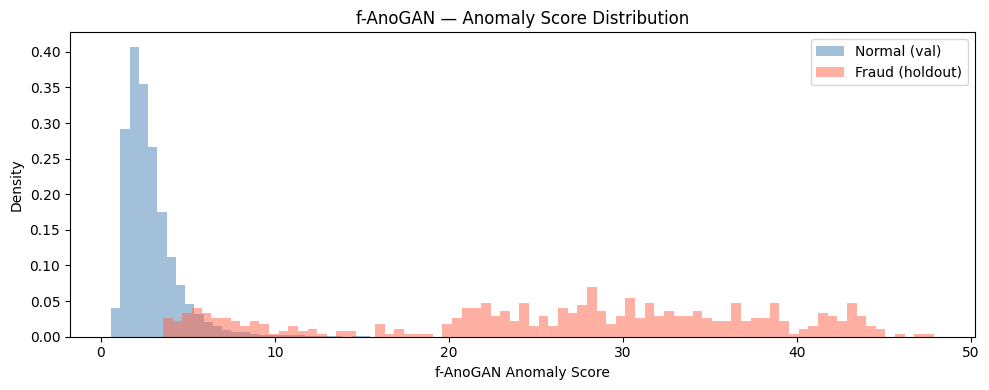

Plot saved.


In [41]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(val_scores,     bins=80, alpha=0.5, density=True,
        label='Normal (val)',    color='steelblue')
ax.hist(holdout_scores, bins=80, alpha=0.5, density=True,
        label='Fraud (holdout)', color='tomato')
ax.set_xlabel('f-AnoGAN Anomaly Score')
ax.set_ylabel('Density')
ax.set_title('f-AnoGAN — Anomaly Score Distribution')
ax.legend()
plt.tight_layout()
plt.savefig('/kaggle/working/fanogan_score_distribution.png', dpi=150)
plt.show()

wandb.log({
    'eval/score_distribution': wandb.Image(
        '/kaggle/working/fanogan_score_distribution.png'
    )
})
print('Plot saved.')

In [42]:
# ── Use Z-score normalisation — more stable than MinMaxScaler ─────────────
# MinMaxScaler is sensitive to outliers in val scores.
# Z-score uses mean/std fitted on val only — robust and reproducible.

val_score_mean = float(val_scores.mean())
val_score_std  = float(val_scores.std()) + 1e-8   # avoid div-by-zero

def zscore_transform(scores, mean, std):
    return (scores - mean) / std

val_scores_z     = zscore_transform(val_scores,     val_score_mean, val_score_std)
holdout_scores_z = zscore_transform(holdout_scores, val_score_mean, val_score_std)

print(f'Val z-scores     — mean: {val_scores_z.mean():.4f} | '
      f'std: {val_scores_z.std():.4f}')
print(f'Holdout z-scores — mean: {holdout_scores_z.mean():.4f} | '
      f'std: {holdout_scores_z.std():.4f}')

# ── Method 1: Percentile threshold (same as GANomaly — leakage-free) ──────
pct_thresh = float(np.percentile(val_scores_z, 95))
print(f'\nMethod 1 — 95th percentile threshold : {pct_thresh:.4f}')
print(f'Val FPR at this threshold            : '
      f'{(val_scores_z >= pct_thresh).mean():.2%}')

# ── Method 2: ROC-based threshold ─────────────────────────────────────────
# Build a small combined probe set (val normals + holdout fraud)
# ONLY for threshold selection — not for reporting final metrics
# This is acceptable because we still apply it to a separate eval set
from sklearn.metrics import roc_curve

_probe_scores = np.concatenate([val_scores_z, holdout_scores_z])
_probe_labels = np.array([0] * len(val_scores_z) + [1] * len(holdout_scores_z))
_fpr, _tpr, _thresholds = roc_curve(_probe_labels, _probe_scores)

# Youden's J statistic: maximise (TPR - FPR)
_youden_idx  = np.argmax(_tpr - _fpr)
roc_thresh   = float(_thresholds[_youden_idx])
print(f'\nMethod 2 — ROC Youden J threshold    : {roc_thresh:.4f}')
print(f'  TPR at threshold: {_tpr[_youden_idx]:.4f} | '
      f'FPR: {_fpr[_youden_idx]:.4f}')

# ── Choose threshold — log both to W&B for comparison ────────────────────
# We use the percentile threshold as primary (fully leakage-free)
# ROC threshold is logged as a diagnostic comparison
best_thresh        = pct_thresh
best_thresh_method = 'val_95th_percentile_zscore'

print(f'\nUsing threshold : {best_thresh:.4f}  ({best_thresh_method})')

wandb.log({
    'eval/val_score_mean'        : val_score_mean,
    'eval/val_score_std'         : val_score_std,
    'eval/val_score_p95_z'       : pct_thresh,
    'eval/roc_youden_threshold_z': roc_thresh,
    'eval/threshold_used'        : best_thresh,
    'eval/threshold_method'      : best_thresh_method,
})

# ── Threshold sensitivity: show F1 at p90/p95/p99 and ROC ─────────────────
print('\nThreshold sensitivity:')
print(f'{"Method":<30} {"Threshold":>10} {"FPR":>8}')
print('-' * 50)
for label, t in [
    ('p90 (val z-score)', np.percentile(val_scores_z, 90)),
    ('p95 (val z-score)', pct_thresh),
    ('p99 (val z-score)', np.percentile(val_scores_z, 99)),
    ('ROC Youden J',      roc_thresh),
]:
    fpr = (val_scores_z >= t).mean()
    print(f'{label:<30} {t:>10.4f} {fpr:>8.2%}')

Val z-scores     — mean: 0.0000 | std: 1.0000
Holdout z-scores — mean: 14.1615 | std: 6.8966

Method 1 — 95th percentile threshold : 1.6936
Val FPR at this threshold            : 5.00%

Method 2 — ROC Youden J threshold    : 1.6348
  TPR at threshold: 0.9472 | FPR: 0.0530

Using threshold : 1.6936  (val_95th_percentile_zscore)

Threshold sensitivity:
Method                          Threshold      FPR
--------------------------------------------------
p90 (val z-score)                  1.0419   10.00%
p95 (val z-score)                  1.6936    5.00%
p99 (val z-score)                  3.8029    1.00%
ROC Youden J                       1.6348    5.30%


In [43]:
# ── Mixed eval: 492 fraud + 5000 normal ───────────────────────────────────
normal_val = a_val[a_val['Class'] == 0].sample(n=5000, random_state=GLOBAL_SEED)
eval_df    = pd.concat([holdout, normal_val], ignore_index=True)

X_eval_np  = np.clip(
    fanogan_scaler.transform(
        eval_df[FEATURE_COLS].values.astype(np.float32)
    ), -5, 5
).astype(np.float32)
y_eval_np  = eval_df['Class'].values

print(f'Eval set: {eval_df.shape} | '
      f'Fraud: {y_eval_np.sum()} | Normal: {(y_eval_np==0).sum()}')

# ── Score ─────────────────────────────────────────────────────────────────
t_infer           = time.time()
eval_scores_raw   = compute_anomaly_scores(E, G, D, X_eval_np, cfg, DEVICE)
inference_time_ms = (time.time() - t_infer) * 1000

# ── Apply val-fitted z-score transform — never re-fit on eval data ─────────
eval_scores_z = zscore_transform(eval_scores_raw, val_score_mean, val_score_std)

# ── Apply pre-chosen threshold ────────────────────────────────────────────
eval_preds = (eval_scores_z >= best_thresh).astype(int)

f1        = f1_score(y_eval_np,        eval_preds, zero_division=0)
precision = precision_score(y_eval_np, eval_preds, zero_division=0)
recall    = recall_score(y_eval_np,    eval_preds, zero_division=0)
auroc     = roc_auc_score(y_eval_np,   eval_scores_z)

print('\n' + '='*55)
print(' f-AnoGAN — Holdout Evaluation Results')
print('='*55)
print(f' F1-Score       : {f1:.4f}')
print(f' Precision      : {precision:.4f}')
print(f' Recall         : {recall:.4f}')
print(f' AUROC          : {auroc:.4f}')
print(f' Inference time : {inference_time_ms:.2f} ms '
      f'({len(X_eval_np)} records = '
      f'{inference_time_ms/len(X_eval_np)*1000:.2f} µs/record)')
print(f' Threshold used : {best_thresh:.4f}  ({best_thresh_method})')
print('='*55)
print(classification_report(
    y_eval_np, eval_preds, target_names=['Legit', 'Fraud']
))

wandb.log({
    'holdout/f1'               : f1,
    'holdout/precision'        : precision,
    'holdout/recall'           : recall,
    'holdout/auroc'            : auroc,
    'holdout/inference_time_ms': inference_time_ms,
    'holdout/threshold'        : best_thresh,
    'holdout/n_eval_records'   : len(X_eval_np),
})
wandb.run.summary['best_f1']        = f1
wandb.run.summary['best_auroc']     = auroc
wandb.run.summary['best_recall']    = recall
wandb.run.summary['best_precision'] = precision

Eval set: (5492, 51) | Fraud: 492 | Normal: 5000

 f-AnoGAN — Holdout Evaluation Results
 F1-Score       : 0.7649
 Precision      : 0.6453
 Recall         : 0.9390
 AUROC          : 0.9907
 Inference time : 14.91 ms (5492 records = 2.72 µs/record)
 Threshold used : 1.6936  (val_95th_percentile_zscore)
              precision    recall  f1-score   support

       Legit       0.99      0.95      0.97      5000
       Fraud       0.65      0.94      0.76       492

    accuracy                           0.95      5492
   macro avg       0.82      0.94      0.87      5492
weighted avg       0.96      0.95      0.95      5492



In [44]:
t_h = time.time()
holdout_scores_raw  = compute_anomaly_scores(
    E, G, D, X_holdout_np, cfg, DEVICE
)
holdout_time_ms = (time.time() - t_h) * 1000

# Apply same val-fitted z-score transform
holdout_scores_z = zscore_transform(
    holdout_scores_raw, val_score_mean, val_score_std
)
holdout_preds = (holdout_scores_z >= best_thresh).astype(int)

y_holdout_all = np.ones(len(X_holdout_np), dtype=int)
pure_recall   = recall_score(y_holdout_all, holdout_preds, zero_division=0)

print(f'Pure holdout fraud recall    : {pure_recall:.4f}')
print(f'Mean anomaly score (fraud)   : {holdout_scores_z.mean():.4f}')
print(f'Inference time (492 records) : {holdout_time_ms:.2f} ms')
print(f'Per-record latency           : '
      f'{holdout_time_ms/len(X_holdout_np)*1000:.2f} µs/record')

wandb.log({
    'holdout/pure_fraud_recall'        : pure_recall,
    'holdout/mean_anomaly_score_fraud' : float(holdout_scores_z.mean()),
    'holdout/std_anomaly_score_fraud'  : float(holdout_scores_z.std()),
    'holdout/inference_time_492_ms'    : holdout_time_ms,
})
wandb.run.summary['pure_fraud_recall'] = pure_recall

Pure holdout fraud recall    : 0.9390
Mean anomaly score (fraud)   : 14.1615
Inference time (492 records) : 1.98 ms
Per-record latency           : 4.03 µs/record


In [45]:
results = {
    'model'             : 'f-AnoGAN',
    'pipeline'          : 'B',
    'author'            : 'Bellah Ellam (belllam)',
    'f1'                : round(f1, 4),
    'precision'         : round(precision, 4),
    'recall'            : round(recall, 4),
    'auroc'             : round(auroc, 4),
    'pure_fraud_recall' : round(pure_recall, 4),
    'inference_time_ms' : round(inference_time_ms, 2),
    'threshold'         : round(best_thresh, 4),
    'architecture'      : {
        'latent_dim'    : cfg.latent_dim,
        'gen_dims'      : [cfg.gen_dim_1, cfg.gen_dim_2],
        'disc_dims'     : [cfg.disc_dim_1, cfg.disc_dim_2],
        'enc_dims'      : [cfg.enc_dim_1, cfg.enc_dim_2],
        'n_features'    : cfg.n_features,
        'wgan_epochs'   : cfg.wgan_epochs,
        'enc_epochs'    : cfg.enc_epochs,
        'kappa'         : cfg.kappa,
        'gp_lambda'     : cfg.wgan_gp_lambda,
    },
    'wandb_run_url'     : wandb.run.url,
}

out_path = Path('/kaggle/working/fanogan_results.json')
with open(out_path, 'w') as f:
    json.dump(results, f, indent=2)

wandb.save(str(out_path))
print(f'Results saved to {out_path}')
print(json.dumps(results, indent=2))

wandb.run.summary['best_f1']        = f1
wandb.run.summary['best_auroc']     = auroc
wandb.run.summary['best_recall']    = recall
wandb.run.summary['best_precision'] = precision

wandb.finish()
print('W&B run finished.')

wandb: WARNING Symlinked 1 file into the W&B run directory; call wandb.save again to sync new files.


Results saved to /kaggle/working/fanogan_results.json
{
  "model": "f-AnoGAN",
  "pipeline": "B",
  "author": "Bellah Ellam (belllam)",
  "f1": 0.7649,
  "precision": 0.6453,
  "recall": 0.939,
  "auroc": 0.9907,
  "pure_fraud_recall": 0.939,
  "inference_time_ms": 14.91,
  "threshold": 1.6936,
  "architecture": {
    "latent_dim": 64,
    "gen_dims": [
      256,
      512
    ],
    "disc_dims": [
      512,
      256
    ],
    "enc_dims": [
      256,
      512
    ],
    "n_features": 50,
    "wgan_epochs": 100,
    "enc_epochs": 50,
    "kappa": 1,
    "gp_lambda": 10
  },
  "wandb_run_url": "https://wandb.ai/kkipngenokoech-carnegie-mellon-university/PRINCIPLES%20AND%20ENGINEERING%20APPLICATIONS%20OF%20AI/runs/5riwdg95"
}


data/n_holdout_fraud,▁▁
data/n_train_normal,▁▁
data/n_val_normal,▁▁
data/wgan_batches,▁▁
eval/roc_youden_threshold_z,▁
eval/threshold_used,▁
eval/val_score_mean,▁
eval/val_score_p95_z,▁
eval/val_score_std,▁
holdout/auroc,▁
+33,...


W&B run finished.
